# Parte 1
Verificación visual. 

In [10]:
pts = [(0, 1), (1, 5), (2, 3)]

pts_1 = [(0, -5), (1, -4), (2, 3)]

pts_2 = [(0, -1), (1, 1), (2, 5), (3, 2)]


In [11]:
def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()

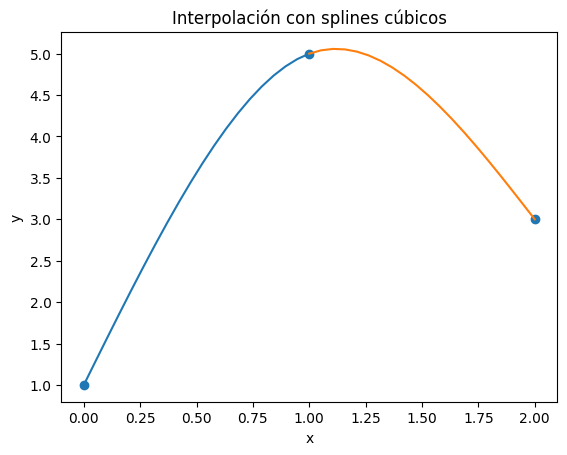

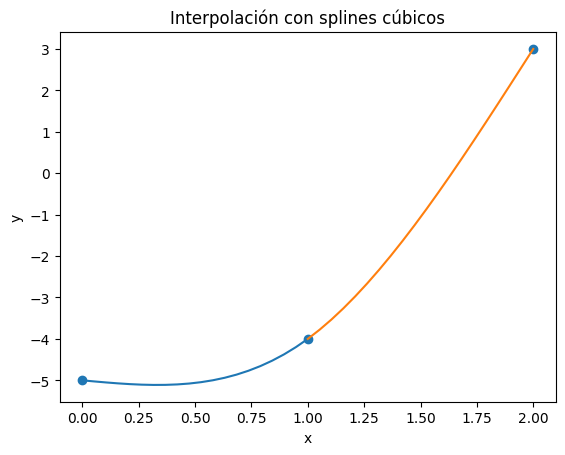

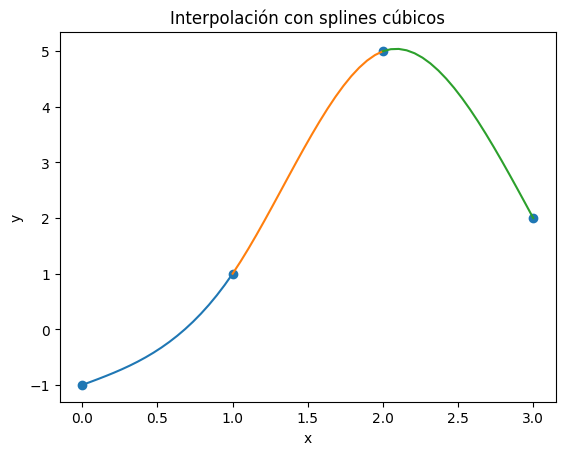

In [ ]:
s = [
    {"a": 1, "b": 5.5, "c": 0, "d": -1.5},
    {"a": 5, "b": 1, "c": -4.5, "d": 1.5},
]

s_1 = [
    {"a": -5, "b": -0.5, "c": 0, "d": 1.5},
    {"a": -4, "b": 4, "c": 4.5, "d": -1.5},
]

s_2 = [
    {"a": -1, "b": 1, "c": 0, "d": 1},
    {"a": 1, "b": 4, "c": 3, "d": -3},
    {"a": 5, "b": 1, "c": -6, "d": 2},
]

dibujar_spline(pts, s)
dibujar_spline(pts_1, s_1)
dibujar_spline(pts_2, s_2)

# Parte 2
Completar código para definir la función Spline.

In [13]:
import sympy as sym
from IPython.display import display


# ###################################################################
def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:
    """
    Cubic spline interpolation ``S``. Every two points are interpolated by a cubic polynomial
    ``S_j`` of the form ``S_j(x) = a_j + b_j(x - x_j) + c_j(x - x_j)^2 + d_j(x - x_j)^3.``

    xs must be different  but not necessarily ordered nor equally spaced.

    ## Parameters
    - xs, ys: points to be interpolated

    ## Return
    - List of symbolic expressions for the cubic spline interpolation.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])  # sort points by x

    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1  # number of splines

    h = [xs[i + 1] - xs[i] for i in range(n)]  # distances between  contiguous xs

    # alpha = # completar
    alpha = [0] * (n + 1)
    for i in range(1, n):
        alpha[i] = 3 / h[i] * (ys[i + 1] - ys[i]) - 3 / h[i - 1] * (ys[i] - ys[i - 1])

    l = [1]
    u = [0]
    z = [0]

    for i in range(1, n):
        l += [2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1]]
        u += [h[i] / l[i]]
        z += [(alpha[i] - h[i - 1] * z[i - 1]) / l[i]]

    l.append(1)
    z.append(0)
    c = [0] * (n + 1)

    x = sym.Symbol("x")
    splines = []
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d = (c[j + 1] - c[j]) / (3 * h[j])
        a = ys[j]
        print(j, a, b, c[j], d)
        S = a + b * (x - xs[j]) + c[j] * (x - xs[j]) ** 2 + d * (x - xs[j]) ** 3

        splines.append(S)
    splines.reverse()
    return splines

In [8]:
xs = [0, 1, 2]
ys = [1, 5, 3]

xs_1 = [0, 1, 2]
ys_1 = [-5, -4, 3]

xs_2 = [0, 1, 2, 3]
ys_2 = [-1, 1, 5, 2]


splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]
_ = [display(s.expand()) for s in splines]
print("________________________________________________")
splines_1 = cubic_spline(xs_1,ys_1)
_ = [display(s) for s in splines_1]
_ = [display(s.expand()) for s in splines_1]
print("________________________________________________")
splines_2 = cubic_spline(xs_2,ys_2)
_ = [display(s) for s in splines_2]
_ = [display(s.expand()) for s in splines_2]


1 5 1.0 -4.5 1.5
0 1 5.5 0.0 -1.5


-1.5*x**3 + 5.5*x + 1

1.0*x + 1.5*(x - 1)**3 - 4.5*(x - 1)**2 + 4.0

-1.5*x**3 + 5.5*x + 1

1.5*x**3 - 9.0*x**2 + 14.5*x - 2.0

...

4.0*x - 3.0*(x - 1)**3 + 3.0*(x - 1)**2 - 3.0

1.0*x + 2.0*(x - 2)**3 - 6.0*(x - 2)**2 + 3.0

1.0*x**3 + 1.0*x - 1

-3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0

2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0

# Parte N03


Animación de la variación de los splines cúbico

In [14]:
import ipywidgets as widgets
from IPython.display import display

x = sym.Symbol("x")

def plot_spline(xs, ys, splines, samples=200):
    plt.figure(figsize=(8, 5))
    for j, S in enumerate(splines):
        x_vals = np.linspace(xs[j], xs[j + 1], samples)
        f = sym.lambdify(x, S, "numpy")
        plt.plot(x_vals, f(x_vals), label=f"S_{j}")
    plt.scatter(xs, ys, color="red", zorder=5)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Spline cúbico interactivo")
    plt.legend()
    plt.grid(True)
    plt.show()

def update_spline(x0, y0, x1, y1, x2, y2):
    with out:
        out.clear_output(wait=True)
        pts = sorted(zip([x0, x1, x2], [y0, y1, y2]), key=lambda p: p[0])
        xs_sorted, ys_sorted = map(list, zip(*pts))
        try:
            splines = cubic_spline(xs=xs_sorted, ys=ys_sorted)
        except Exception as e:
            print("Error al calcular el spline:", e)
            return
        plot_spline(xs_sorted, ys_sorted, splines)
        print("Ecuaciones de los splines:")
        for j, S in enumerate(splines):
            display(sym.Eq(sym.Symbol(f"S_{j}(x)"), S))

x0 = widgets.FloatSlider(value=xs[0], min=-5, max=5, step=0.1, description="x0")
y0 = widgets.FloatSlider(value=ys[0], min=-10, max=10, step=0.1, description="y0")
x1 = widgets.FloatSlider(value=xs[1], min=-5, max=5, step=0.1, description="x1")
y1 = widgets.FloatSlider(value=ys[1], min=-10, max=10, step=0.1, description="y1")
x2 = widgets.FloatSlider(value=xs[2], min=-5, max=5, step=0.1, description="x2")
y2 = widgets.FloatSlider(value=ys[2], min=-10, max=10, step=0.1, description="y2")

controls = widgets.VBox([
    widgets.HBox([x0, y0]),
    widgets.HBox([x1, y1]),
    widgets.HBox([x2, y2]),
])

out = widgets.Output()

def on_value_change(change):
    update_spline(x0.value, y0.value, x1.value, y1.value, x2.value, y2.value)

for widget in [x0, y0, x1, y1, x2, y2]:
    widget.observe(on_value_change, names="value")

display(controls, out)
update_spline(x0.value, y0.value, x1.value, y1.value, x2.value, y2.value)

Output()